# Simple GluonTS Example

This example can be found [here](https://ts.gluon.ai/stable/index.html#simple-example).

To illustrate how to use GluonTS, we train a DeepAR-model and make predictions using the airpassengers dataset. The dataset consists of a single time series of monthly passenger numbers between 1949 and 1960. We train the model on the first nine years and make predictions for the remaining three years.

1. Import packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from gluonts.torch import DeepAREstimator

c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\gluonts\json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


2. Load the data from a CSV file into a PandasDataset

In [2]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/AileenNielsen/"
    "TimeSeriesAnalysisWithPython/master/data/AirPassengers.csv",
    index_col=0,
    parse_dates=True,
)
dataset = PandasDataset(df, target="#Passengers")

3. Split the data for training and testing

In [3]:
training_data, test_gen = split(dataset, offset=-36)
test_data = test_gen.generate_instances(prediction_length=12, windows=3)

4. Train the model and make predictions

In [4]:
model = DeepAREstimator(
    prediction_length=12, freq="M", trainer_kwargs={"max_epochs": 5}
).train(training_data)

forecasts = list(model.predict(test_data.input))

c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\gluonts\time_feature\_base.py:249: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  offset = to_offset(freq_str)
c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\gluonts\time_feature\lag.py:104: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  offset = to_offset(freq_str)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip instal

Epoch 0: |          | 50/? [00:02<00:00, 20.16it/s, v_num=0, train_loss=5.630]

Epoch 0, global step 50: 'train_loss' reached 5.62501 (best 5.62501), saving model to 'c:\\Users\\Mike\\vscode\\TEMPO_prob\\gluonts\\lightning_logs\\version_0\\checkpoints\\epoch=0-step=50.ckpt' as top 1


Epoch 1: |          | 50/? [00:02<00:00, 21.63it/s, v_num=0, train_loss=4.800]

Epoch 1, global step 100: 'train_loss' reached 4.79825 (best 4.79825), saving model to 'c:\\Users\\Mike\\vscode\\TEMPO_prob\\gluonts\\lightning_logs\\version_0\\checkpoints\\epoch=1-step=100.ckpt' as top 1


...

Epoch 3, global step 200: 'train_loss' reached 4.26600 (best 4.26600), saving model to 'c:\\Users\\Mike\\vscode\\TEMPO_prob\\gluonts\\lightning_logs\\version_0\\checkpoints\\epoch=3-step=200.ckpt' as top 1


Epoch 4: |          | 50/? [00:02<00:00, 17.28it/s, v_num=0, train_loss=4.120]

Epoch 4, global step 250: 'train_loss' reached 4.11560 (best 4.11560), saving model to 'c:\\Users\\Mike\\vscode\\TEMPO_prob\\gluonts\\lightning_logs\\version_0\\checkpoints\\epoch=4-step=250.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: |          | 50/? [00:02<00:00, 17.20it/s, v_num=0, train_loss=4.120]


c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\gluonts\time_feature\lag.py:104: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  offset = to_offset(freq_str)


5. Plot predictions. Note, the forecasts are displayed in terms of a probability distribution and the shaded areas represent the 50% and 90% prediction intervals.

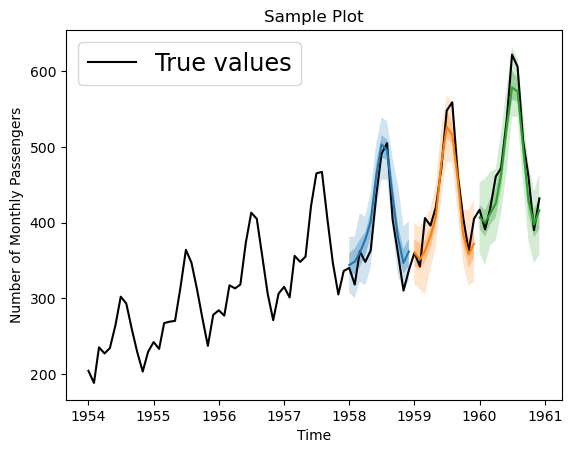

In [6]:
plt.plot(df["1954":], color="black")
for forecast in forecasts:
    forecast.plot()
plt.legend(["True values"], loc="upper left", fontsize="xx-large")
plt.xlabel("Time")
plt.ylabel("Number of Monthly Passengers")
plt.title("Sample Plot")
plt.show()